# E-Commerce Sales — 전체 탐색적 데이터 분석 (EDA)

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

# workflows/ 기준 상대 경로 (normpath로 .. 구간 정규화)
BASE    = os.path.dirname(os.path.abspath('ecommerce_eda.ipynb'))
IN_DIR  = os.path.normpath(os.path.join(BASE, '..', 'resources'))
OUT_DIR = os.path.normpath(os.path.join(BASE, '..', 'output'))
os.makedirs(OUT_DIR, exist_ok=True)
print('IN_DIR :', IN_DIR)
print('OUT_DIR:', OUT_DIR)

df = pd.read_csv(os.path.join(IN_DIR, 'ecommerce_sales.csv'))
print('로드 완료:', df.shape)
display(df)  # 데이터셋 전체를 pandas dataframe으로 출력

IN_DIR : G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\01_Full_EDA\resources
OUT_DIR: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\01_Full_EDA\output


로드 완료: (260, 11)


,order_id,customer_id,customer_name,product,category,region,order_date,revenue,quantity,discount,status
0,ORD001,CUST101,Alice Johnson,Wireless Headphones,Electronics,North,2024-01-05,89.99,1.0,0.10,Completed
1,ORD002,CUST102,Bob Smith,Running Shoes,Sports,South,2024-01-06,45.50,1.0,0.00,Completed
2,ORD003,CUST103,Carol Davis,Winter Jacket,Clothing,East,2024-01-07,120.00,1.0,0.15,Completed
3,ORD004,CUST104,David Wilson,Desk Lamp,Home,West,2024-01-08,34.99,NaN,0.05,Completed
4,ORD005,CUST105,Emma Brown,Coffee Maker,Home,North,2024-01-09,79.99,1.0,NaN,Completed
...,...,...,...,...,...,...,...,...,...,...,...
255,ORD256,CUST155,Chloe Reed,Running Shoes,Sports,West,2024-12-31,65.00,2.0,NaN,Completed
256,ORD257,CUST156,Dylan Cook,Nightstand,Home,North,2024-12-31,99.99,1.0,0.05,Cancelled
257,ORD258,CUST157,Ella Morgan,Jeans,Clothing,South,2024-12-31,65.00,1.0,0.10,Completed
258,ORD259,CUST158,Felix Bell,Webcam,Electronics,East,2024-12-31,89.99,1.0,0.00,Pending


## 1. 데이터셋 기본 정보 — shape / dtypes / 결측값

In [2]:
print('Shape:', df.shape)
print('\n[데이터 타입]')
print(df.dtypes)

# 결측값 개수와 비율 함께 출력
missing = df.isnull().sum()
print('\n[결측값 요약]')
print(pd.DataFrame({'결측수': missing, '결측률(%)': (missing / len(df) * 100).round(2)}))

df.head(100)

Shape: (260, 11)

[데이터 타입]
order_id             str
customer_id          str
customer_name        str
product              str
category             str
region               str
order_date           str
revenue          float64
quantity         float64
discount         float64
status               str
dtype: object

[결측값 요약]
               결측수  결측률(%)
order_id         0    0.00
customer_id      0    0.00
customer_name    0    0.00
product          0    0.00
category         0    0.00
region           0    0.00
order_date       0    0.00
revenue         17    6.54
quantity         3    1.15
discount        48   18.46
status           0    0.00


,order_id,customer_id,customer_name,product,category,region,order_date,revenue,quantity,discount,status
0,ORD001,CUST101,Alice Johnson,Wireless Headphones,Electronics,North,2024-01-05,89.99,1.0,0.10,Completed
1,ORD002,CUST102,Bob Smith,Running Shoes,Sports,South,2024-01-06,45.50,1.0,0.00,Completed
2,ORD003,CUST103,Carol Davis,Winter Jacket,Clothing,East,2024-01-07,120.00,1.0,0.15,Completed
3,ORD004,CUST104,David Wilson,Desk Lamp,Home,West,2024-01-08,34.99,NaN,0.05,Completed
4,ORD005,CUST105,Emma Brown,Coffee Maker,Home,North,2024-01-09,79.99,1.0,NaN,Completed
...,...,...,...,...,...,...,...,...,...,...,...
95,ORD096,CUST195,Quinn Alexander,Bicycle,Sports,West,2024-05-16,299.99,1.0,NaN,Completed
96,ORD097,CUST196,Rachel Russell,Desk Chair,Home,North,2024-05-17,249.99,1.0,0.10,Completed
97,ORD098,CUST197,Samuel Griffin,Dress Pants,Clothing,South,2024-05-18,85.00,1.0,0.00,Cancelled
98,ORD099,CUST198,Tanya Hayes,Laptop Stand,Electronics,East,2024-05-19,49.99,1.0,0.15,Completed


## 2. 수치형 열 기술 통계량

In [3]:
df.describe().round(2)

,revenue,quantity,discount
count,243.00,257.00,212.00
mean,104.03,1.25,0.07
std,104.09,0.76,0.06
min,-15.00,1.00,0.00
25%,45.25,1.00,0.00
50%,65.00,1.00,0.08
75%,109.99,1.00,0.10
max,899.99,5.00,0.20


## 3. Revenue & Quantity 분포 플롯

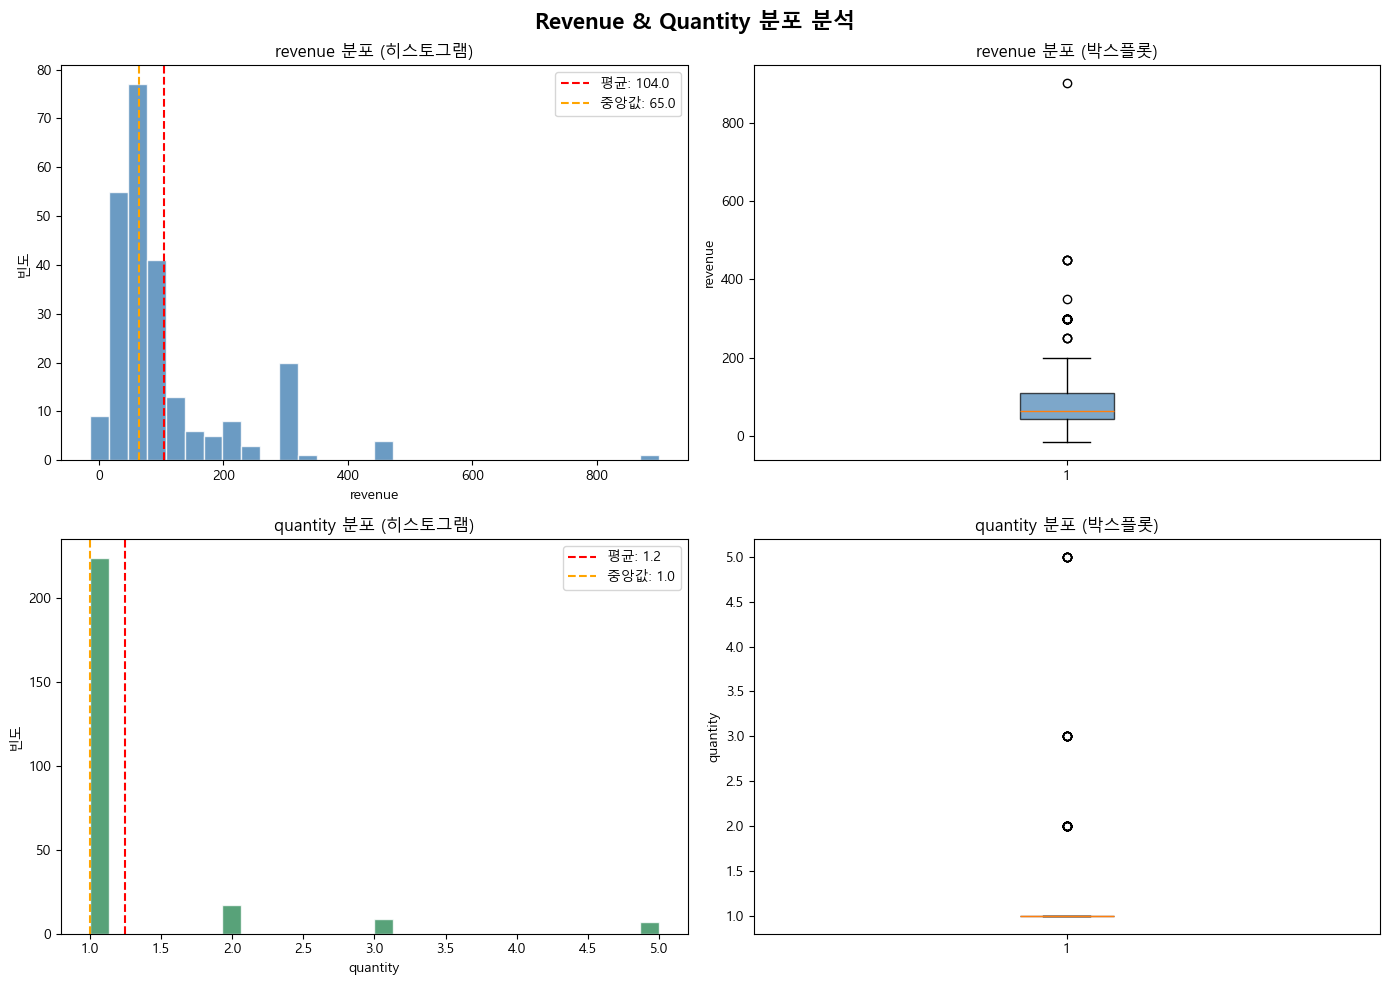

저장: output/revenue_quantity_distribution.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Revenue & Quantity 분포 분석', fontsize=16, fontweight='bold')

for row_i, (col, color) in enumerate([('revenue', 'steelblue'), ('quantity', 'seagreen')]):
    data = df[col].dropna()

    # 히스토그램 + 평균/중앙값 수직선
    axes[row_i, 0].hist(data, bins=30, color=color, edgecolor='white', alpha=0.8)
    axes[row_i, 0].set_title(f'{col} 분포 (히스토그램)')
    axes[row_i, 0].set_xlabel(col)
    axes[row_i, 0].set_ylabel('빈도')
    axes[row_i, 0].axvline(data.mean(),   color='red',    linestyle='--', label=f'평균: {data.mean():.1f}')
    axes[row_i, 0].axvline(data.median(), color='orange', linestyle='--', label=f'중앙값: {data.median():.1f}')
    axes[row_i, 0].legend()

    # 박스플롯
    axes[row_i, 1].boxplot(data, patch_artist=True, boxprops=dict(facecolor=color, alpha=0.7))
    axes[row_i, 1].set_title(f'{col} 분포 (박스플롯)')
    axes[row_i, 1].set_ylabel(col)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'revenue_quantity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: output/revenue_quantity_distribution.png')

## 4. 수치형 열 상관관계 히트맵

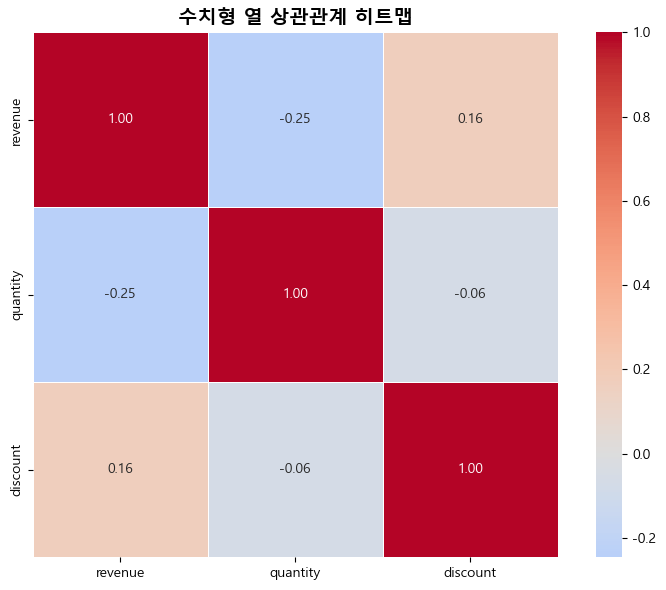

저장: output/correlation_heatmap.png


In [5]:
# 수치형 열만 추출해 상관계수 계산
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('수치형 열 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: output/correlation_heatmap.png')

## 5. 총 매출 기준 상위 5개 상품 및 카테고리

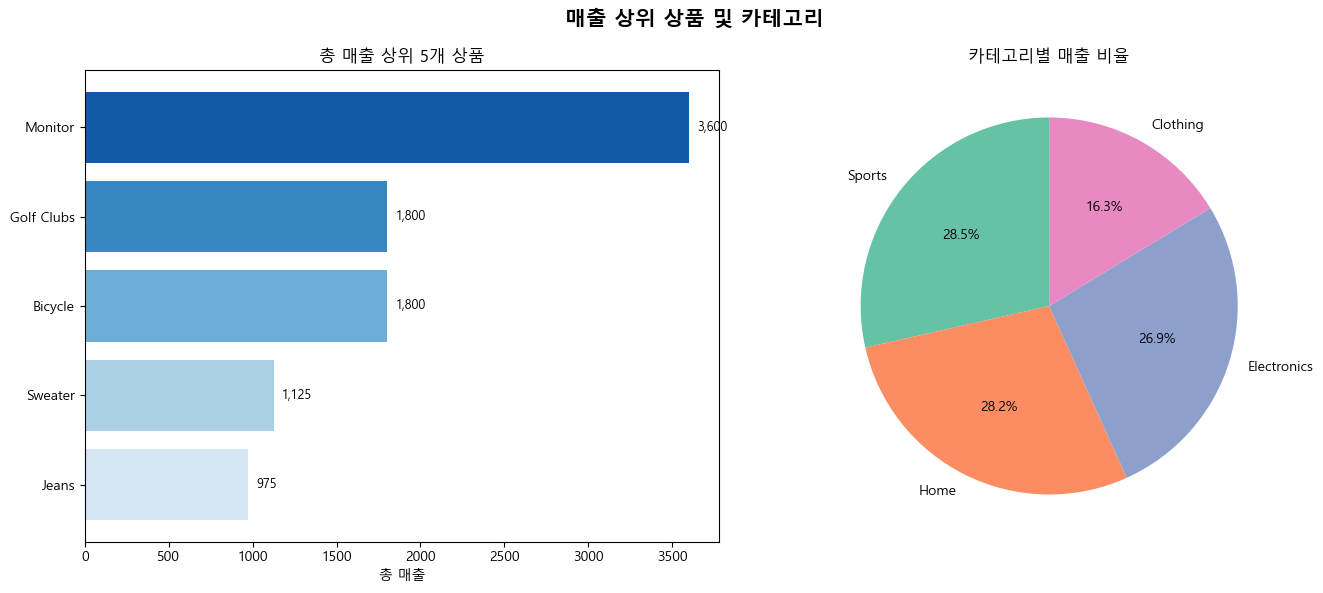

저장: output/top5_products_categories.png


In [6]:
top5_prod = df.groupby('product')['revenue'].sum().nlargest(5).reset_index()
top5_cat  = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('매출 상위 상품 및 카테고리', fontsize=15, fontweight='bold')

# 상위 5개 상품 수평 막대그래프
bars = axes[0].barh(top5_prod['product'], top5_prod['revenue'],
                    color=sns.color_palette('Blues_r', len(top5_prod)))
axes[0].set_title('총 매출 상위 5개 상품')
axes[0].set_xlabel('총 매출')
for bar, val in zip(bars, top5_prod['revenue']):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}', va='center', fontsize=9)
axes[0].invert_yaxis()

# 카테고리별 매출 파이 차트
axes[1].pie(top5_cat['revenue'], labels=top5_cat['category'],
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(top5_cat)), startangle=90)
axes[1].set_title('카테고리별 매출 비율')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'top5_products_categories.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: output/top5_products_categories.png')

## 6. 지역별 매출 분석

region     총매출       평균매출  주문수
  West 7205.69 110.856769   65
 North 7184.54 149.677917   65
  East 6838.36 105.205538   65
 South 4050.38  62.313538   65


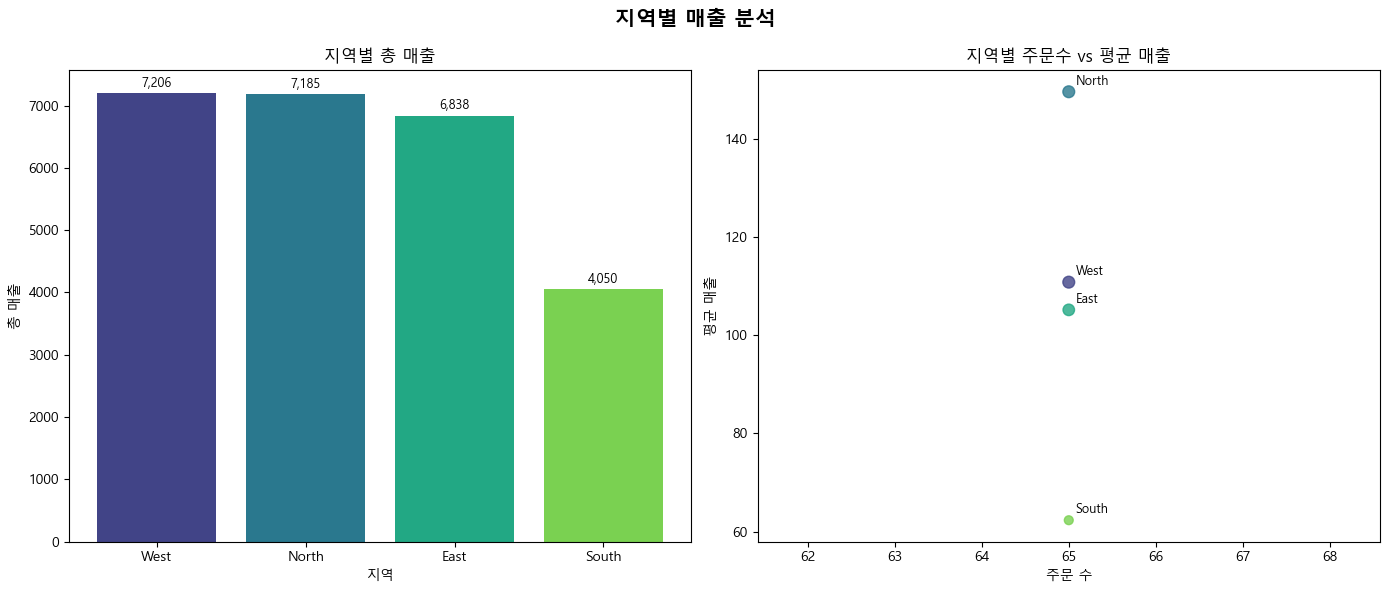

저장: output/regional_revenue.png


In [7]:
# 지역별 집계
regional = df.groupby('region').agg(
    총매출=('revenue', 'sum'),
    평균매출=('revenue', 'mean'),
    주문수=('order_id', 'count')
).reset_index().sort_values('총매출', ascending=False)
print(regional.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('지역별 매출 분석', fontsize=15, fontweight='bold')
colors_r = sns.color_palette('viridis', len(regional))

# 지역별 총 매출 막대그래프
bars = axes[0].bar(regional['region'], regional['총매출'], color=colors_r)
axes[0].set_title('지역별 총 매출')
axes[0].set_xlabel('지역')
axes[0].set_ylabel('총 매출')
for bar, val in zip(bars, regional['총매출']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', fontsize=9)

# 주문 수 vs 평균 매출 산점도 (버블 크기 = 총매출)
axes[1].scatter(regional['주문수'], regional['평균매출'],
                s=regional['총매출'] / 100, c=colors_r, alpha=0.8)
for _, row in regional.iterrows():
    axes[1].annotate(row['region'], (row['주문수'], row['평균매출']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1].set_title('지역별 주문수 vs 평균 매출')
axes[1].set_xlabel('주문 수')
axes[1].set_ylabel('평균 매출')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'regional_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: output/regional_revenue.png')

## 7. 이상값 및 데이터 품질 분석

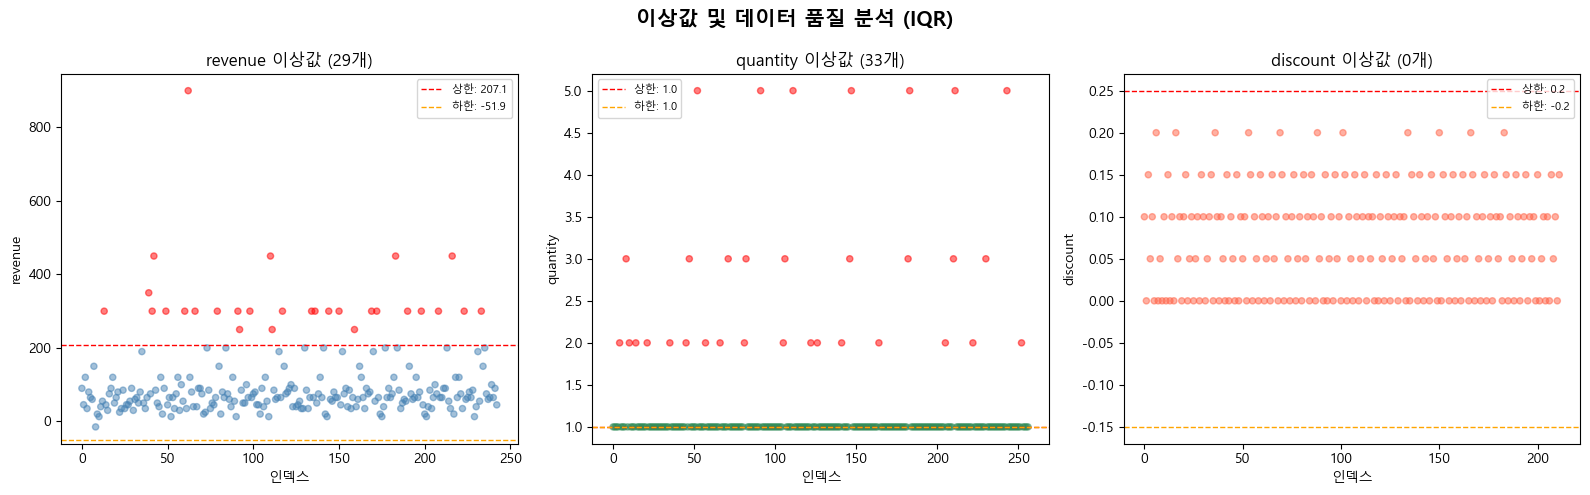

저장: output/outliers_data_quality.png
  revenue: 이상값 29개 / IQR 범위 [-51.86, 207.10]
  quantity: 이상값 33개 / IQR 범위 [1.00, 1.00]
  discount: 이상값 0개 / IQR 범위 [-0.15, 0.25]


In [8]:
def iqr_bounds(s):
    """IQR 방식으로 이상값 경계 계산"""
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('이상값 및 데이터 품질 분석 (IQR)', fontsize=15, fontweight='bold')

for ax, col, color in zip(axes, ['revenue', 'quantity', 'discount'],
                           ['steelblue', 'seagreen', 'tomato']):
    data   = df[col].dropna().reset_index(drop=True)
    lo, hi = iqr_bounds(data)
    is_out = (data < lo) | (data > hi)

    # 이상값은 빨간색, 정상값은 해당 색상으로 표시
    ax.scatter(data.index, data, c=['red' if o else color for o in is_out], alpha=0.5, s=20)
    ax.axhline(hi, color='red',    linestyle='--', linewidth=1, label=f'상한: {hi:.1f}')
    ax.axhline(lo, color='orange', linestyle='--', linewidth=1, label=f'하한: {lo:.1f}')
    ax.set_title(f'{col} 이상값 ({is_out.sum()}개)')
    ax.set_xlabel('인덱스')
    ax.set_ylabel(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'outliers_data_quality.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: output/outliers_data_quality.png')

# 이상값 요약 출력
for col in ['revenue', 'quantity', 'discount']:
    data = df[col].dropna()
    lo, hi = iqr_bounds(data)
    cnt = ((data < lo) | (data > hi)).sum()
    print(f'  {col}: 이상값 {cnt}개 / IQR 범위 [{lo:.2f}, {hi:.2f}]')

## 8. Excel 저장 및 주요 발견 요약

In [9]:
# Excel 파일을 output/ 에 저장
df.to_excel(os.path.join(OUT_DIR, 'ecommerce_sales.xlsx'), index=False, sheet_name='Sales Data')
print('저장: output/ecommerce_sales.xlsx')

print('\n=== EDA 주요 발견 사항 ===')
print(f'데이터셋     : {df.shape[0]}행 x {df.shape[1]}열')
print(f'결측값       : 총 {df.isnull().sum().sum()}개  (discount {df["discount"].isnull().sum()}개 / revenue {df["revenue"].isnull().sum()}개)')
print(f'총 매출      : {df["revenue"].sum():,.0f}')
print(f'상위 상품    : {df.groupby("product")["revenue"].sum().idxmax()}')
print(f'상위 카테고리: {df.groupby("category")["revenue"].sum().idxmax()}')
print(f'상위 지역    : {df.groupby("region")["revenue"].sum().idxmax()}')
rev_lo, rev_hi = iqr_bounds(df['revenue'].dropna())
print(f'Revenue 이상값: {((df["revenue"] < rev_lo) | (df["revenue"] > rev_hi)).sum()}개 (음수 포함)')
print(f'중복 주문ID  : {df["order_id"].duplicated().sum()}개')

저장: output/ecommerce_sales.xlsx

=== EDA 주요 발견 사항 ===
데이터셋     : 260행 x 11열
결측값       : 총 68개  (discount 48개 / revenue 17개)
총 매출      : 25,279
상위 상품    : Monitor
상위 카테고리: Sports
상위 지역    : West
Revenue 이상값: 29개 (음수 포함)
중복 주문ID  : 0개
